
# Part B — 11 Probabilistic Snowfall Forecast

## Goal

The point-forecast experiments showed that the current ML model does **not** beat climatology strongly enough to replace it.

So this notebook asks a different question:

> Can we produce a calibrated **probabilistic** snowfall forecast rather than pretending one snowfall number is certain?

We compare:

1. **Probabilistic climatology** — an empirical distribution from the most recent historical winters
2. **ElasticNet + NAO challenger** — point prediction plus leakage-safe historical forecast residuals to represent uncertainty

For each winter, the system produces:

- expected / central snowfall estimate
- **80% prediction interval**
- probability of **below-normal**
- probability of **near-normal**
- probability of **above-normal**

## Evaluation

We evaluate:

- multiclass **Brier score**
- Brier skill relative to probabilistic climatology
- category accuracy
- 80% interval coverage
- average interval width
- probability calibration

## Leakage protection

Every historical forecast uses only information that existed before that winter.

The category boundaries and climatology distribution are also calculated using **prior winters only**.


In [1]:

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import ElasticNetCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 190)

cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"
REPORTS_DIR = PROJECT_ROOT / "reports"
MODELS_DIR = PROJECT_ROOT / "models"

for directory in [PROCESSED_DIR, FIGURES_DIR, REPORTS_DIR, MODELS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

STRICT_HISTORY_PATH = PROCESSED_DIR / "forecast_features_full.csv"
FINAL_MODEL_DATA_PATH = PROCESSED_DIR / "final_model_dataset.csv"

if not STRICT_HISTORY_PATH.exists():
    raise FileNotFoundError(
        "forecast_features_full.csv was not found. Run notebook 09 first."
    )

if not FINAL_MODEL_DATA_PATH.exists():
    raise FileNotFoundError(
        "final_model_dataset.csv was not found. Run notebook 10c first."
    )

print("Project root:", PROJECT_ROOT)


Project root: /Users/toor/Desktop/Weather-Prediction/toronto-climate-analysis


## 1. Load strict snowfall history and challenger modeling data

In [2]:

strict_history = pd.read_csv(STRICT_HISTORY_PATH)
model_data = pd.read_csv(FINAL_MODEL_DATA_PATH)

strict_history = (
    strict_history[
        ["season_year", "snowfall_cm"]
    ]
    .dropna()
    .drop_duplicates("season_year")
    .sort_values("season_year")
    .reset_index(drop=True)
)

model_data = (
    model_data
    .sort_values("season_year")
    .reset_index(drop=True)
)

print("Strict-quality snowfall seasons:", len(strict_history))
print(
    "Strict history range:",
    strict_history["season_year"].min(),
    "→",
    strict_history["season_year"].max()
)

print("\nML challenger rows:", len(model_data))
print(
    "ML range:",
    model_data["season_year"].min(),
    "→",
    model_data["season_year"].max()
)

display(strict_history.head())
display(model_data.head())


Strict-quality snowfall seasons: 84
Strict history range: 1939 → 2026

ML challenger rows: 70
ML range: 1951 → 2026


,season_year,snowfall_cm
0,1939,207.4
1,1941,164.0
2,1942,96.9
3,1943,182.4
4,1944,123.7


,season_year,snowfall_cm,valid_days,missing_days,measurable_snow_days,expected_days,coverage_pct,usable_90pct,full_calendar_window,usable,winter_coverage_pct,usable_strict,snowfall_clean_cm,snow_lag1_cm,snow_roll5_mean_cm,snow_roll10_mean_cm,snow_roll10_std_cm,previous_season_usable,oni_jas,oni_phase_threshold,sep_oct_mean_temp_c,sep_oct_total_precip_mm,sep_oct_temp_coverage_pct,sep_oct_precip_coverage_pct,autumn_features_usable,year_index,ao_jas,ao_jas_valid_months,nao_jas,nao_jas_valid_months,pna_jas,pna_jas_valid_months,pdo_jas,pdo_jas_valid_months
0,1951,111.8,365,0,40,365,100.0,True,True,True,100.0,True,111.8,196.4,136.22,141.04,35.388077,True,-0.57,cool_threshold,12.640984,100.0,100.0,100.0,True,12.0,-0.431833,3,-0.353333,3,-0.253333,3,-2.137000,3
1,1952,184.8,366,0,43,366,100.0,True,True,True,100.0,True,184.8,111.8,140.68,135.82,35.474836,True,0.90,warm_threshold,12.634426,102.3,100.0,100.0,True,13.0,-0.368400,3,-0.070000,3,-0.006667,3,-0.171000,3
2,1953,53.9,365,0,23,365,100.0,True,True,True,100.0,True,53.9,184.8,148.28,144.61,35.649231,True,-0.20,neutral_threshold,11.896721,77.4,100.0,100.0,True,14.0,-0.010233,3,-0.303333,3,0.033333,3,-0.947000,3
3,1954,124.7,365,0,38,365,100.0,True,True,True,100.0,True,124.7,53.9,134.68,131.76,42.929922,True,0.68,warm_threshold,13.195082,92.5,100.0,100.0,True,15.0,0.359933,3,-0.220000,3,-0.166667,3,-0.280333,3
4,1955,109.3,365,0,44,365,100.0,True,True,True,100.0,True,109.3,124.7,134.32,131.86,42.910222,True,-0.83,cool_threshold,13.193443,294.6,100.0,100.0,True,16.0,0.173333,3,-0.980000,3,0.073333,3,-0.170667,3



### Why two datasets?

For **climatology**, we can use every trustworthy snowfall season.

For the ML challenger, we can only use winters where all pre-winter predictors are available.

This avoids unnecessarily throwing away good snowfall history just because a climate-index feature is missing.


## 2. Final challenger feature set

In [3]:

FINAL_FEATURES = [
    "oni_jas",
    "nao_jas",
    "sep_oct_mean_temp_c",
    "sep_oct_total_precip_mm",
    "snow_lag1_cm",
    "snow_roll5_mean_cm",
    "snow_roll10_mean_cm",
    "snow_roll10_std_cm",
    "year_index",
]

missing = [
    col for col in FINAL_FEATURES
    if col not in model_data.columns
]

if missing:
    raise KeyError(
        f"Missing challenger features: {missing}"
    )

assert model_data[
    ["season_year", "snowfall_cm"] + FINAL_FEATURES
].notna().all().all()

print("Features:")
for feature in FINAL_FEATURES:
    print("-", feature)


Features:
- oni_jas
- nao_jas
- sep_oct_mean_temp_c
- sep_oct_total_precip_mm
- snow_lag1_cm
- snow_roll5_mean_cm
- snow_roll10_mean_cm
- snow_roll10_std_cm
- year_index



## 3. Probabilistic forecast definitions

### Climate-normal window

For each historical forecast, use up to the **30 most recent prior trustworthy winters**.

This allows the reference distribution to evolve rather than using future winters.

### Below / near / above normal

Within that historical window:

- **Below normal**: snowfall ≤ historical 33rd percentile
- **Near normal**: between the 33rd and 67th percentiles
- **Above normal**: snowfall > historical 67th percentile

### 80% prediction interval

- lower bound = predictive 10th percentile
- upper bound = predictive 90th percentile

The thresholds are recomputed for every walk-forward year using prior data only.


In [4]:

CLIMATOLOGY_WINDOW = 30
INTERVAL_ALPHA = 0.20
LOWER_Q = INTERVAL_ALPHA / 2
UPPER_Q = 1 - INTERVAL_ALPHA / 2

MIN_TRAIN_SIZE = 20

print("Climatology window:", CLIMATOLOGY_WINDOW)
print("Prediction interval:", int((1 - INTERVAL_ALPHA) * 100), "%")


Climatology window: 30
Prediction interval: 80 %


## 4. Helper functions

In [5]:

def make_elasticnet(n_train):
    n_splits = min(
        5,
        max(2, n_train // 6)
    )

    return Pipeline([
        ("scaler", StandardScaler()),
        (
            "model",
            ElasticNetCV(
                l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
                alphas=np.logspace(-3, 2, 60),
                cv=TimeSeriesSplit(n_splits=n_splits),
                max_iter=20000,
            )
        ),
    ])


def category_thresholds(history_values):
    q33 = float(
        np.quantile(history_values, 1 / 3)
    )
    q67 = float(
        np.quantile(history_values, 2 / 3)
    )

    return q33, q67


def snow_category(value, q33, q67):
    if value <= q33:
        return "below"
    elif value <= q67:
        return "near"
    else:
        return "above"


def distribution_summary(samples, q33, q67):
    samples = np.asarray(samples, dtype=float)
    samples = samples[np.isfinite(samples)]

    if len(samples) == 0:
        raise ValueError("Predictive distribution is empty.")

    probs = {
        "p_below": float(np.mean(samples <= q33)),
        "p_near": float(
            np.mean(
                (samples > q33)
                & (samples <= q67)
            )
        ),
        "p_above": float(np.mean(samples > q67)),
    }

    return {
        "mean_cm": float(np.mean(samples)),
        "median_cm": float(np.median(samples)),
        "lower80_cm": float(np.quantile(samples, LOWER_Q)),
        "upper80_cm": float(np.quantile(samples, UPPER_Q)),
        **probs,
    }


def multiclass_brier_row(
    actual_category,
    p_below,
    p_near,
    p_above
):
    probs = np.array(
        [p_below, p_near, p_above],
        dtype=float
    )

    outcome = np.array([
        1.0 if actual_category == "below" else 0.0,
        1.0 if actual_category == "near" else 0.0,
        1.0 if actual_category == "above" else 0.0,
    ])

    # Multiclass Brier score: sum of squared probability errors.
    return float(
        np.sum((probs - outcome) ** 2)
    )



## 5. Leakage-safe challenger uncertainty

ElasticNet gives a point prediction, not a probability distribution.

To estimate uncertainty without using the future, each walk-forward training set is split again:

```text
older training winters
        ↓
fit temporary ElasticNet
        ↓
most recent calibration winters
        ↓
calculate signed forecast residuals
        ↓
fit ElasticNet on full outer training history
        ↓
test-winter point forecast + calibration residual distribution
```

The calibration residuals represent historical forecast misses.

This is a simple **empirical residual / conformal-style** uncertainty approach. It is intentionally transparent and appropriate for a small portfolio dataset.


In [6]:

def challenger_predictive_distribution(
    outer_train,
    test_row,
    features,
):
    n = len(outer_train)

    # Use roughly the latest quarter of the available outer training history
    # for leakage-safe residual calibration, with practical small-sample bounds.
    calibration_size = max(
        10,
        int(round(0.25 * n))
    )
    calibration_size = min(
        calibration_size,
        15
    )

    if n - calibration_size < 8:
        raise ValueError(
            "Not enough proper-training rows after calibration split."
        )

    proper_train = outer_train.iloc[:-calibration_size].copy()
    calibration = outer_train.iloc[-calibration_size:].copy()

    # Fit only on data before the calibration period.
    calibration_model = make_elasticnet(
        len(proper_train)
    )

    calibration_model.fit(
        proper_train[features],
        proper_train["snowfall_cm"]
    )

    calibration_predictions = (
        calibration_model.predict(
            calibration[features]
        )
    )

    # Signed residual = observed - predicted.
    residuals = (
        calibration["snowfall_cm"].to_numpy()
        - calibration_predictions
    )

    # Final point model uses all outer-training data.
    final_model = make_elasticnet(
        len(outer_train)
    )

    final_model.fit(
        outer_train[features],
        outer_train["snowfall_cm"]
    )

    point_prediction = float(
        final_model.predict(
            test_row[features]
        )[0]
    )

    predictive_samples = (
        point_prediction + residuals
    )

    return (
        point_prediction,
        predictive_samples,
        calibration_size
    )


## 6. Walk-forward probabilistic backtest

In [7]:

if len(model_data) <= MIN_TRAIN_SIZE:
    raise ValueError(
        f"Need more than {MIN_TRAIN_SIZE} challenger rows."
    )

records = []

for test_idx in range(
    MIN_TRAIN_SIZE,
    len(model_data)
):
    outer_train = model_data.iloc[:test_idx].copy()
    test = model_data.iloc[[test_idx]].copy()

    season_year = int(
        test["season_year"].iloc[0]
    )
    actual_cm = float(
        test["snowfall_cm"].iloc[0]
    )

    # ---------------------------------------------------------
    # Historical reference distribution:
    # prior strict-quality winters only
    # ---------------------------------------------------------
    prior_history = strict_history[
        strict_history["season_year"] < season_year
    ].copy()

    climatology_sample = (
        prior_history["snowfall_cm"]
        .tail(CLIMATOLOGY_WINDOW)
        .to_numpy(dtype=float)
    )

    if len(climatology_sample) < 20:
        # Skip very early periods that do not have enough climatology history.
        continue

    q33, q67 = category_thresholds(
        climatology_sample
    )

    actual_category = snow_category(
        actual_cm,
        q33,
        q67
    )

    # ---------------------------------------------------------
    # Model 1: probabilistic climatology
    # ---------------------------------------------------------
    clim_summary = distribution_summary(
        climatology_sample,
        q33,
        q67
    )

    records.append({
        "season_year": season_year,
        "method": "Probabilistic Climatology",
        "actual_cm": actual_cm,
        "actual_category": actual_category,
        "below_threshold_cm": q33,
        "above_threshold_cm": q67,
        "point_prediction_cm": clim_summary["mean_cm"],
        "median_prediction_cm": clim_summary["median_cm"],
        "lower80_cm": clim_summary["lower80_cm"],
        "upper80_cm": clim_summary["upper80_cm"],
        "p_below": clim_summary["p_below"],
        "p_near": clim_summary["p_near"],
        "p_above": clim_summary["p_above"],
        "calibration_n": np.nan,
    })

    # ---------------------------------------------------------
    # Model 2: ElasticNet + NAO + calibrated residuals
    # ---------------------------------------------------------
    point_pred, ml_samples, calibration_n = (
        challenger_predictive_distribution(
            outer_train,
            test,
            FINAL_FEATURES
        )
    )

    ml_summary = distribution_summary(
        ml_samples,
        q33,
        q67
    )

    records.append({
        "season_year": season_year,
        "method": "ElasticNet + NAO Residual",
        "actual_cm": actual_cm,
        "actual_category": actual_category,
        "below_threshold_cm": q33,
        "above_threshold_cm": q67,
        "point_prediction_cm": point_pred,
        "median_prediction_cm": ml_summary["median_cm"],
        "lower80_cm": ml_summary["lower80_cm"],
        "upper80_cm": ml_summary["upper80_cm"],
        "p_below": ml_summary["p_below"],
        "p_near": ml_summary["p_near"],
        "p_above": ml_summary["p_above"],
        "calibration_n": calibration_n,
    })

prob_predictions = pd.DataFrame(records)

print("Rows:", len(prob_predictions))
print(
    "Forecast winters:",
    prob_predictions["season_year"].nunique()
)

display(prob_predictions.head(10))


Rows: 100
Forecast winters: 50


,season_year,method,actual_cm,actual_category,below_threshold_cm,above_threshold_cm,point_prediction_cm,median_prediction_cm,lower80_cm,upper80_cm,p_below,p_near,p_above,calibration_n
0,1971,Probabilistic Climatology,171.7,above,120.366667,149.300000,133.710000,129.250000,95.440000,182.640000,0.333333,0.333333,0.333333,NaN
1,1971,ElasticNet + NAO Residual,171.7,above,120.366667,149.300000,129.632276,132.567306,102.783337,178.463238,0.400000,0.300000,0.300000,10.0
2,1972,Probabilistic Climatology,188.9,above,120.366667,149.300000,133.966667,129.250000,95.440000,182.640000,0.333333,0.333333,0.333333,NaN
3,1972,ElasticNet + NAO Residual,188.9,above,120.366667,149.300000,133.849630,154.751530,109.822118,186.263769,0.200000,0.200000,0.600000,10.0
4,1973,Probabilistic Climatology,110.0,below,122.966667,155.666667,137.033333,133.450000,95.440000,185.210000,0.333333,0.333333,0.333333,NaN
5,1973,ElasticNet + NAO Residual,110.0,below,122.966667,155.666667,136.968094,165.408499,111.861312,202.155977,0.200000,0.200000,0.600000,10.0
6,1974,Probabilistic Climatology,127.8,near,120.366667,149.300000,134.620000,129.250000,95.440000,185.210000,0.333333,0.333333,0.333333,NaN
7,1974,ElasticNet + NAO Residual,127.8,near,120.366667,149.300000,129.398952,160.823750,120.850164,196.463256,0.100000,0.300000,0.600000,10.0
8,1975,Probabilistic Climatology,124.6,near,120.366667,149.300000,134.756667,129.900000,95.440000,185.210000,0.333333,0.333333,0.333333,NaN
9,1975,ElasticNet + NAO Residual,124.6,near,120.366667,149.300000,132.826373,148.264125,114.545355,197.017614,0.200000,0.300000,0.500000,10.0


## 7. Score every probabilistic forecast

In [8]:

prob_predictions["brier_score"] = prob_predictions.apply(
    lambda r: multiclass_brier_row(
        r["actual_category"],
        r["p_below"],
        r["p_near"],
        r["p_above"],
    ),
    axis=1
)

prob_predictions["inside_80_interval"] = (
    (prob_predictions["actual_cm"] >= prob_predictions["lower80_cm"])
    & (prob_predictions["actual_cm"] <= prob_predictions["upper80_cm"])
)

prob_predictions["interval_width_cm"] = (
    prob_predictions["upper80_cm"]
    - prob_predictions["lower80_cm"]
)

prob_predictions["predicted_category"] = (
    prob_predictions[
        ["p_below", "p_near", "p_above"]
    ]
    .idxmax(axis=1)
    .str.replace("p_", "", regex=False)
)

prob_predictions["category_correct"] = (
    prob_predictions["predicted_category"]
    == prob_predictions["actual_category"]
)

display(
    prob_predictions[
        [
            "season_year",
            "method",
            "actual_cm",
            "actual_category",
            "point_prediction_cm",
            "lower80_cm",
            "upper80_cm",
            "p_below",
            "p_near",
            "p_above",
            "brier_score",
            "inside_80_interval",
        ]
    ].head(12)
)


,season_year,method,actual_cm,actual_category,point_prediction_cm,lower80_cm,upper80_cm,p_below,p_near,p_above,brier_score,inside_80_interval
0,1971,Probabilistic Climatology,171.7,above,133.710000,95.440000,182.640000,0.333333,0.333333,0.333333,0.666667,True
1,1971,ElasticNet + NAO Residual,171.7,above,129.632276,102.783337,178.463238,0.400000,0.300000,0.300000,0.740000,True
2,1972,Probabilistic Climatology,188.9,above,133.966667,95.440000,182.640000,0.333333,0.333333,0.333333,0.666667,False
3,1972,ElasticNet + NAO Residual,188.9,above,133.849630,109.822118,186.263769,0.200000,0.200000,0.600000,0.240000,False
4,1973,Probabilistic Climatology,110.0,below,137.033333,95.440000,185.210000,0.333333,0.333333,0.333333,0.666667,True
5,1973,ElasticNet + NAO Residual,110.0,below,136.968094,111.861312,202.155977,0.200000,0.200000,0.600000,1.040000,False
6,1974,Probabilistic Climatology,127.8,near,134.620000,95.440000,185.210000,0.333333,0.333333,0.333333,0.666667,True
7,1974,ElasticNet + NAO Residual,127.8,near,129.398952,120.850164,196.463256,0.100000,0.300000,0.600000,0.860000,True
8,1975,Probabilistic Climatology,124.6,near,134.756667,95.440000,185.210000,0.333333,0.333333,0.333333,0.666667,True
9,1975,ElasticNet + NAO Residual,124.6,near,132.826373,114.545355,197.017614,0.200000,0.300000,0.500000,0.780000,True


## 8. Overall probabilistic comparison

In [9]:

prob_comparison = (
    prob_predictions
    .groupby("method")
    .agg(
        n_forecasts=("season_year", "count"),
        mean_brier=("brier_score", "mean"),
        category_accuracy=("category_correct", "mean"),
        interval_coverage=("inside_80_interval", "mean"),
        mean_interval_width_cm=("interval_width_cm", "mean"),
    )
    .reset_index()
)

clim_brier = float(
    prob_comparison.loc[
        prob_comparison["method"]
        == "Probabilistic Climatology",
        "mean_brier"
    ].iloc[0]
)

prob_comparison["brier_skill_vs_climatology_pct"] = (
    1
    - prob_comparison["mean_brier"] / clim_brier
) * 100

display(
    prob_comparison.style.format({
        "n_forecasts": "{:.0f}",
        "mean_brier": "{:.3f}",
        "category_accuracy": "{:.1%}",
        "interval_coverage": "{:.1%}",
        "mean_interval_width_cm": "{:.1f}",
        "brier_skill_vs_climatology_pct": "{:+.1f}%"
    })
)


,method,n_forecasts,mean_brier,category_accuracy,interval_coverage,mean_interval_width_cm,brier_skill_vs_climatology_pct
0,ElasticNet + NAO Residual,50,0.716,40.0%,64.0%,75.8,-7.6%
1,Probabilistic Climatology,50,0.666,44.0%,68.0%,81.2,+0.0%



### Interpretation

For Brier score:

- **lower is better**
- positive Brier skill means the challenger improves on probabilistic climatology
- negative skill means it is worse

For an intended 80% prediction interval:

- coverage near 80% is desirable
- very low coverage means intervals are too narrow
- extremely high coverage with huge widths may be uninformative


## 9. Recent 15-winter probabilistic performance

In [10]:

test_years = sorted(
    prob_predictions["season_year"].unique()
)

recent_years = test_years[-15:]

recent_prob = prob_predictions[
    prob_predictions["season_year"]
    .isin(recent_years)
]

recent_comparison = (
    recent_prob
    .groupby("method")
    .agg(
        n_forecasts=("season_year", "count"),
        mean_brier=("brier_score", "mean"),
        category_accuracy=("category_correct", "mean"),
        interval_coverage=("inside_80_interval", "mean"),
        mean_interval_width_cm=("interval_width_cm", "mean"),
    )
    .reset_index()
)

recent_clim_brier = float(
    recent_comparison.loc[
        recent_comparison["method"]
        == "Probabilistic Climatology",
        "mean_brier"
    ].iloc[0]
)

recent_comparison["brier_skill_vs_climatology_pct"] = (
    1
    - recent_comparison["mean_brier"]
      / recent_clim_brier
) * 100

display(
    recent_comparison.style.format({
        "n_forecasts": "{:.0f}",
        "mean_brier": "{:.3f}",
        "category_accuracy": "{:.1%}",
        "interval_coverage": "{:.1%}",
        "mean_interval_width_cm": "{:.1f}",
        "brier_skill_vs_climatology_pct": "{:+.1f}%"
    })
)


,method,n_forecasts,mean_brier,category_accuracy,interval_coverage,mean_interval_width_cm,brier_skill_vs_climatology_pct
0,ElasticNet + NAO Residual,15,0.713,40.0%,66.7%,91.0,-7.6%
1,Probabilistic Climatology,15,0.662,33.3%,66.7%,80.2,+0.0%


## 10. Category calibration summary

In [11]:

calibration_rows = []

for method, g in prob_predictions.groupby("method"):
    for category in ["below", "near", "above"]:
        p_col = f"p_{category}"

        observed = (
            g["actual_category"] == category
        ).astype(float)

        calibration_rows.append({
            "method": method,
            "category": category,
            "mean_forecast_probability": g[p_col].mean(),
            "observed_frequency": observed.mean(),
            "calibration_gap": (
                g[p_col].mean()
                - observed.mean()
            )
        })

calibration_summary = pd.DataFrame(
    calibration_rows
)

display(
    calibration_summary.style.format({
        "mean_forecast_probability": "{:.1%}",
        "observed_frequency": "{:.1%}",
        "calibration_gap": "{:+.1%}",
    })
)


,method,category,mean_forecast_probability,observed_frequency,calibration_gap
0,ElasticNet + NAO Residual,below,43.5%,44.0%,-0.5%
1,ElasticNet + NAO Residual,near,28.5%,28.0%,+0.5%
2,ElasticNet + NAO Residual,above,28.0%,28.0%,-0.0%
3,Probabilistic Climatology,below,33.7%,44.0%,-10.3%
4,Probabilistic Climatology,near,32.9%,28.0%,+4.9%
5,Probabilistic Climatology,above,33.3%,28.0%,+5.3%


## 11. Reliability bins

In [12]:

reliability_rows = []

bins = [-0.001, 0.20, 0.40, 0.60, 0.80, 1.001]
labels = ["0–20%", "20–40%", "40–60%", "60–80%", "80–100%"]

for method, g in prob_predictions.groupby("method"):
    for category in ["below", "near", "above"]:
        p_col = f"p_{category}"

        temp = g[
            ["season_year", "actual_category", p_col]
        ].copy()

        temp["bin"] = pd.cut(
            temp[p_col],
            bins=bins,
            labels=labels
        )

        temp["observed"] = (
            temp["actual_category"] == category
        ).astype(float)

        grouped = (
            temp.groupby(
                "bin",
                observed=False
            )
            .agg(
                n=("season_year", "count"),
                mean_probability=(p_col, "mean"),
                observed_frequency=("observed", "mean"),
            )
            .reset_index()
        )

        grouped["method"] = method
        grouped["category"] = category

        reliability_rows.append(grouped)

reliability = pd.concat(
    reliability_rows,
    ignore_index=True
)

display(
    reliability[
        reliability["n"] > 0
    ].style.format({
        "mean_probability": "{:.1%}",
        "observed_frequency": "{:.1%}",
    })
)


,bin,n,mean_probability,observed_frequency,method,category
0,0–20%,8,15.0%,37.5%,ElasticNet + NAO Residual,below
1,20–40%,17,36.0%,41.2%,ElasticNet + NAO Residual,below
2,40–60%,15,49.6%,46.7%,ElasticNet + NAO Residual,below
3,60–80%,10,70.1%,50.0%,ElasticNet + NAO Residual,below
5,0–20%,18,18.4%,27.8%,ElasticNet + NAO Residual,near
6,20–40%,26,30.8%,30.8%,ElasticNet + NAO Residual,near
7,40–60%,6,48.9%,16.7%,ElasticNet + NAO Residual,near
10,0–20%,19,9.4%,36.8%,ElasticNet + NAO Residual,above
11,20–40%,22,33.3%,22.7%,ElasticNet + NAO Residual,above
12,40–60%,8,52.0%,25.0%,ElasticNet + NAO Residual,above


## 12. Plot Brier-score comparison

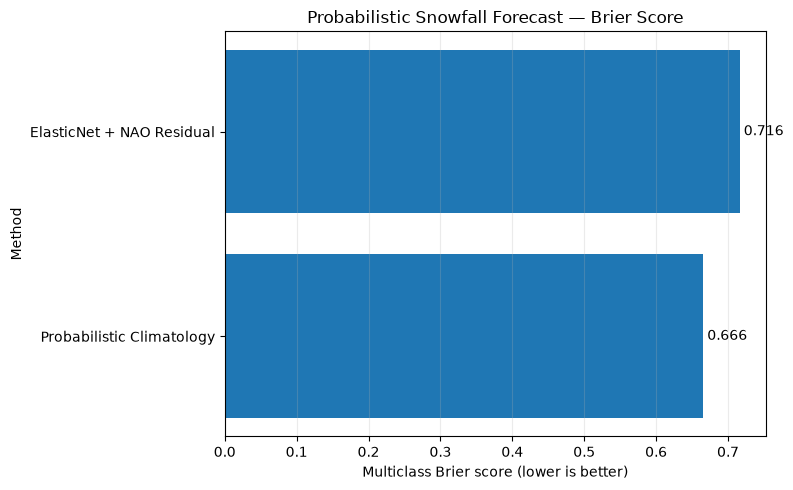

In [13]:

plot_data = (
    prob_comparison
    .sort_values("mean_brier")
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    plot_data["method"],
    plot_data["mean_brier"]
)

ax.set_title(
    "Probabilistic Snowfall Forecast — Brier Score"
)
ax.set_xlabel("Multiclass Brier score (lower is better)")
ax.set_ylabel("Method")
ax.grid(axis="x", alpha=0.25)

for i, value in enumerate(plot_data["mean_brier"]):
    ax.text(
        value,
        i,
        f" {value:.3f}",
        va="center"
    )

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "part_b_probabilistic_brier.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 13. Plot interval coverage and width

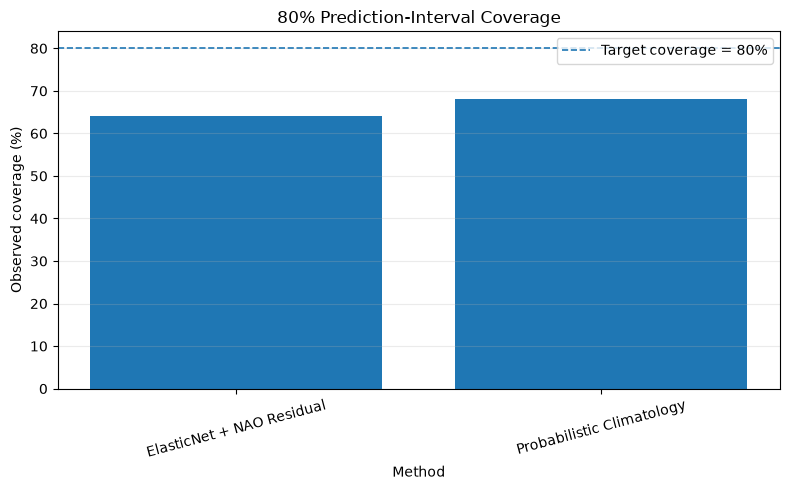

In [14]:

fig, ax = plt.subplots(figsize=(8, 5))

coverage_plot = prob_comparison.copy()

ax.bar(
    coverage_plot["method"],
    coverage_plot["interval_coverage"] * 100
)

ax.axhline(
    80,
    linestyle="--",
    linewidth=1.2,
    label="Target coverage = 80%"
)

ax.set_title("80% Prediction-Interval Coverage")
ax.set_ylabel("Observed coverage (%)")
ax.set_xlabel("Method")
ax.tick_params(axis="x", rotation=15)
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "part_b_interval_coverage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 14. Inspect the largest probabilistic failures

In [15]:

prob_predictions["interval_miss_distance_cm"] = np.where(
    prob_predictions["actual_cm"] < prob_predictions["lower80_cm"],
    prob_predictions["lower80_cm"] - prob_predictions["actual_cm"],
    np.where(
        prob_predictions["actual_cm"] > prob_predictions["upper80_cm"],
        prob_predictions["actual_cm"] - prob_predictions["upper80_cm"],
        0.0
    )
)

for method in prob_predictions["method"].unique():
    print("\n", "=" * 70)
    print(method)
    print("=" * 70)

    display(
        prob_predictions[
            prob_predictions["method"] == method
        ]
        .nlargest(
            8,
            "brier_score"
        )[
            [
                "season_year",
                "actual_cm",
                "actual_category",
                "point_prediction_cm",
                "lower80_cm",
                "upper80_cm",
                "p_below",
                "p_near",
                "p_above",
                "brier_score",
            ]
        ]
    )



Probabilistic Climatology


,season_year,actual_cm,actual_category,point_prediction_cm,lower80_cm,upper80_cm,p_below,p_near,p_above,brier_score
60,2004,120.8,near,113.423333,78.16,146.29,0.366667,0.300000,0.333333,0.735556
54,2001,138.0,above,114.916667,79.57,155.20,0.366667,0.300000,0.333333,0.668889
58,2003,150.7,above,114.123333,78.16,147.55,0.366667,0.300000,0.333333,0.668889
62,2005,148.1,above,111.153333,78.16,145.26,0.366667,0.300000,0.333333,0.668889
0,1971,171.7,above,133.710000,95.44,182.64,0.333333,0.333333,0.333333,0.666667
2,1972,188.9,above,133.966667,95.44,182.64,0.333333,0.333333,0.333333,0.666667
4,1973,110.0,below,137.033333,95.44,185.21,0.333333,0.333333,0.333333,0.666667
6,1974,127.8,near,134.620000,95.44,185.21,0.333333,0.333333,0.333333,0.666667



ElasticNet + NAO Residual


,season_year,actual_cm,actual_category,point_prediction_cm,lower80_cm,upper80_cm,p_below,p_near,p_above,brier_score
19,1980,79.7,below,145.815011,142.184677,191.595084,0.000000,0.300000,0.700000,1.580000
45,1996,145.2,above,120.129551,57.004121,117.156881,0.700000,0.300000,0.000000,1.580000
47,1997,144.4,above,123.079070,60.210225,127.354892,0.636364,0.272727,0.090909,1.305785
51,1999,116.1,near,122.764444,73.215880,139.993010,0.636364,0.090909,0.272727,1.305785
21,1981,81.8,below,132.777337,118.183926,176.741808,0.100000,0.500000,0.400000,1.220000
29,1985,145.8,above,129.596473,64.598417,142.748030,0.500000,0.400000,0.100000,1.220000
55,2001,138.0,above,118.622406,68.853474,132.708291,0.666667,0.166667,0.166667,1.166667
59,2003,150.7,above,119.433362,68.554741,136.612352,0.666667,0.166667,0.166667,1.166667



## 15. Conservative production decision

The point-forecast stage already selected **historical climatology** as the production benchmark.

For the probabilistic challenger to replace it, require:

1. **Brier score improvement ≥ 3%**
2. 80% interval coverage between **70% and 90%**
3. average interval width no more than **20% wider** than climatology

These are project-level engineering gates, not universal meteorological standards.


In [16]:

decision = prob_comparison.copy()

clim_row = decision[
    decision["method"]
    == "Probabilistic Climatology"
].iloc[0]

decision["coverage_ok"] = (
    decision["interval_coverage"]
    .between(0.70, 0.90)
)

decision["width_ok"] = (
    decision["mean_interval_width_cm"]
    <= clim_row["mean_interval_width_cm"] * 1.20
)

decision["brier_skill_ok"] = (
    decision["brier_skill_vs_climatology_pct"]
    >= 3.0
)

decision["passes_probabilistic_gate"] = (
    decision["coverage_ok"]
    & decision["width_ok"]
    & decision["brier_skill_ok"]
)

challenger_row = decision[
    decision["method"]
    == "ElasticNet + NAO Residual"
].iloc[0]

if challenger_row["passes_probabilistic_gate"]:
    PRODUCTION_METHOD = "ElasticNet + NAO Residual"
    PRODUCTION_DECISION = (
        "Probabilistic challenger passes the practical skill gate."
    )
else:
    PRODUCTION_METHOD = "Probabilistic Climatology"
    PRODUCTION_DECISION = (
        "Probabilistic challenger does not pass the practical skill gate; "
        "retain climatology as production benchmark."
    )

display(
    decision.style.format({
        "mean_brier": "{:.3f}",
        "category_accuracy": "{:.1%}",
        "interval_coverage": "{:.1%}",
        "mean_interval_width_cm": "{:.1f}",
        "brier_skill_vs_climatology_pct": "{:+.1f}%"
    })
)

print("\nDecision:", PRODUCTION_DECISION)
print("Production probabilistic method:", PRODUCTION_METHOD)


,method,n_forecasts,mean_brier,category_accuracy,interval_coverage,mean_interval_width_cm,brier_skill_vs_climatology_pct,coverage_ok,width_ok,brier_skill_ok,passes_probabilistic_gate
0,ElasticNet + NAO Residual,50,0.716,40.0%,64.0%,75.8,-7.6%,False,True,False,False
1,Probabilistic Climatology,50,0.666,44.0%,68.0%,81.2,+0.0%,False,True,False,False



Decision: Probabilistic challenger does not pass the practical skill gate; retain climatology as production benchmark.
Production probabilistic method: Probabilistic Climatology


## 16. Current baseline outlook for the next season


Even when the ML challenger cannot yet produce a future forecast because some pre-winter climate features are unavailable, the production climatology can always issue a baseline probability distribution.

The following uses the most recent 30 trustworthy completed winters.


In [17]:

NEXT_SEASON_YEAR = int(
    strict_history["season_year"].max() + 1
)

latest_climatology = (
    strict_history["snowfall_cm"]
    .tail(CLIMATOLOGY_WINDOW)
    .to_numpy(dtype=float)
)

next_q33, next_q67 = category_thresholds(
    latest_climatology
)

next_summary = distribution_summary(
    latest_climatology,
    next_q33,
    next_q67
)

next_outlook = pd.DataFrame([{
    "season_year": NEXT_SEASON_YEAR,
    "method": "Probabilistic Climatology",
    "expected_snowfall_cm": next_summary["mean_cm"],
    "median_snowfall_cm": next_summary["median_cm"],
    "lower80_cm": next_summary["lower80_cm"],
    "upper80_cm": next_summary["upper80_cm"],
    "below_normal_threshold_cm": next_q33,
    "above_normal_threshold_cm": next_q67,
    "p_below": next_summary["p_below"],
    "p_near": next_summary["p_near"],
    "p_above": next_summary["p_above"],
}])

display(
    next_outlook.style.format({
        "expected_snowfall_cm": "{:.1f}",
        "median_snowfall_cm": "{:.1f}",
        "lower80_cm": "{:.1f}",
        "upper80_cm": "{:.1f}",
        "below_normal_threshold_cm": "{:.1f}",
        "above_normal_threshold_cm": "{:.1f}",
        "p_below": "{:.1%}",
        "p_near": "{:.1%}",
        "p_above": "{:.1%}",
    })
)


,season_year,method,expected_snowfall_cm,median_snowfall_cm,lower80_cm,upper80_cm,below_normal_threshold_cm,above_normal_threshold_cm,p_below,p_near,p_above
0,2027,Probabilistic Climatology,117.1,124.8,65.3,154.6,95.4,138.4,33.3%,33.3%,33.3%



### Important

A climatological forecast will naturally assign roughly one-third probability to each tercile because those categories are defined from the climatological distribution itself.

Later, when current ENSO / NAO / autumn climate features are available, the challenger system can shift those probabilities.

For example:

```text
Climatology
Below: 33%
Near: 33%
Above: 33%

Updated climate-signal model
Below: 52%
Near: 31%
Above: 17%
```

Only the second forecast is useful if it is demonstrably calibrated and skillful in historical backtesting.


## 17. Save probabilistic outputs

In [18]:

PRED_PATH = (
    PROCESSED_DIR
    / "probabilistic_walk_forward_predictions.csv"
)

COMPARE_PATH = (
    PROCESSED_DIR
    / "probabilistic_model_comparison.csv"
)

CALIBRATION_PATH = (
    PROCESSED_DIR
    / "probabilistic_calibration_summary.csv"
)

NEXT_OUTLOOK_PATH = (
    PROCESSED_DIR
    / "next_season_climatology_outlook.csv"
)

METADATA_PATH = (
    MODELS_DIR
    / "probabilistic_forecast_metadata.json"
)

prob_predictions.to_csv(
    PRED_PATH,
    index=False
)

prob_comparison.to_csv(
    COMPARE_PATH,
    index=False
)

calibration_summary.to_csv(
    CALIBRATION_PATH,
    index=False
)

next_outlook.to_csv(
    NEXT_OUTLOOK_PATH,
    index=False
)

metadata = {
    "production_method": PRODUCTION_METHOD,
    "production_decision": PRODUCTION_DECISION,
    "climatology_window": CLIMATOLOGY_WINDOW,
    "prediction_interval": "80%",
    "category_definition": {
        "below": "<= rolling historical 33rd percentile",
        "near": "between rolling historical 33rd and 67th percentiles",
        "above": "> rolling historical 67th percentile",
    },
    "challenger_features": FINAL_FEATURES,
}

with open(
    METADATA_PATH,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        metadata,
        f,
        indent=2
    )

print("Saved:")
print(PRED_PATH)
print(COMPARE_PATH)
print(CALIBRATION_PATH)
print(NEXT_OUTLOOK_PATH)
print(METADATA_PATH)


Saved:
/Users/toor/Desktop/Weather-Prediction/toronto-climate-analysis/data/processed/probabilistic_walk_forward_predictions.csv
/Users/toor/Desktop/Weather-Prediction/toronto-climate-analysis/data/processed/probabilistic_model_comparison.csv
/Users/toor/Desktop/Weather-Prediction/toronto-climate-analysis/data/processed/probabilistic_calibration_summary.csv
/Users/toor/Desktop/Weather-Prediction/toronto-climate-analysis/data/processed/next_season_climatology_outlook.csv
/Users/toor/Desktop/Weather-Prediction/toronto-climate-analysis/models/probabilistic_forecast_metadata.json


## 18. Generate probabilistic forecast report

In [19]:

report = [
    "# Toronto Seasonal Snowfall — Probabilistic Forecast Report",
    "",
    f"- Walk-forward winters evaluated: {prob_predictions['season_year'].nunique()}",
    f"- Climatology window: latest {CLIMATOLOGY_WINDOW} prior trustworthy winters",
    "- Prediction interval: 80%",
    "",
    "## Probabilistic backtest",
    "",
]

for _, row in prob_comparison.iterrows():
    report.append(
        f"- {row['method']}: "
        f"Brier={row['mean_brier']:.3f}, "
        f"category accuracy={row['category_accuracy']:.1%}, "
        f"80% interval coverage={row['interval_coverage']:.1%}, "
        f"mean interval width={row['mean_interval_width_cm']:.1f} cm, "
        f"Brier skill vs climatology={row['brier_skill_vs_climatology_pct']:+.1f}%"
    )

report.extend([
    "",
    "## Production decision",
    "",
    f"**{PRODUCTION_METHOD}**",
    "",
    PRODUCTION_DECISION,
    "",
    "## Next-season climatological baseline",
    "",
    f"- Expected snowfall: {next_summary['mean_cm']:.1f} cm",
    f"- 80% interval: {next_summary['lower80_cm']:.1f}–{next_summary['upper80_cm']:.1f} cm",
    f"- Below-normal probability: {next_summary['p_below']:.1%}",
    f"- Near-normal probability: {next_summary['p_near']:.1%}",
    f"- Above-normal probability: {next_summary['p_above']:.1%}",
])

REPORT_PATH = (
    REPORTS_DIR
    / "part_b_probabilistic_forecast_report.md"
)

REPORT_PATH.write_text(
    "\n".join(report),
    encoding="utf-8"
)

print(REPORT_PATH.read_text())


# Toronto Seasonal Snowfall — Probabilistic Forecast Report

- Walk-forward winters evaluated: 50
- Climatology window: latest 30 prior trustworthy winters
- Prediction interval: 80%

## Probabilistic backtest

- ElasticNet + NAO Residual: Brier=0.716, category accuracy=40.0%, 80% interval coverage=64.0%, mean interval width=75.8 cm, Brier skill vs climatology=-7.6%
- Probabilistic Climatology: Brier=0.666, category accuracy=44.0%, 80% interval coverage=68.0%, mean interval width=81.2 cm, Brier skill vs climatology=+0.0%

## Production decision

**Probabilistic Climatology**

Probabilistic challenger does not pass the practical skill gate; retain climatology as production benchmark.

## Next-season climatological baseline

- Expected snowfall: 117.1 cm
- 80% interval: 65.3–154.6 cm
- Below-normal probability: 33.3%
- Near-normal probability: 33.3%
- Above-normal probability: 33.3%



# Next stage

After running this notebook, send:

1. **overall probabilistic comparison**
2. **recent 15-winter comparison**
3. **calibration summary**
4. **production probabilistic method**
5. **next-season climatological outlook**

Then the forecasting research layer is essentially complete.

After that we can build the production system:

```text
new ENSO / climate data
        ↓
refresh features
        ↓
generate probabilistic forecast
        ↓
compare with previous forecast
        ↓
material probability change?
        ↓
agent-written report
        ↓
dashboard + email alert
```

And separately:

```text
completed winter
        ↓
actual snowfall becomes known
        ↓
retraining pipeline
        ↓
benchmark / challenger evaluation
        ↓
promote only if skill gate passes
```
